## Image Classification Submission


> Dataset diperoleh dari [kaggle](https://www.kaggle.com/datasets/vencerlanz09/bottle-synthetic-images-dataset)

> Dataset berisi 5 kelas data klasifikasi botol


> Jumlah dataset 25000 gambar dengan resolusi yang berbeda-beda

### Import Library

In [1]:
import importlib.util
import subprocess
import sys

required_packages = [
    "kagglehub",
    "tensorflow",
    "tensorflowjs",
    "numpy",
    "opencv-python",
    "pandas",
    "matplotlib",
    "seaborn",
]

missing_packages = [pkg for pkg in required_packages if importlib.util.find_spec(pkg.split("-")[0]) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

import kagglehub
import os
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import cv2
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

d:\IDCAMP\Gen AI\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Prepare Data from Kaggle API

In [2]:
try:
    path = kagglehub.dataset_download("vencerlanz09/bottle-synthetic-images-dataset")
    print("Path to dataset files:", path)
except Exception as err:
    raise RuntimeError(
        "Download gagal. Pastikan koneksi internet aktif, lalu jalankan ulang cell ini."
    ) from err

Path to dataset files: C:\Users\Victus\.cache\kagglehub\datasets\vencerlanz09\bottle-synthetic-images-dataset\versions\7


In [3]:
data = os.path.join(path, "Bottle Images", "Bottle Images")

### Kelas data pada Dataset

In [4]:
class_names = os.listdir(data)
class_names

['Beer Bottles',
 'Plastic Bottles',
 'Soda Bottle',
 'Water Bottle',
 'Wine Bottle']

### Sample Image Data dengan Resolusi yang berbeda-beda

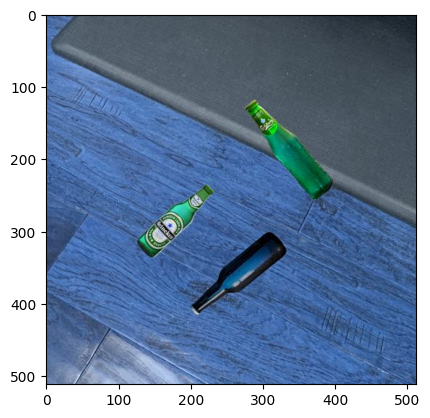

In [5]:
img = cv2.imread(os.path.join(data, 'Beer Bottles', '00000000.jpg'))
plt.imshow(img)
plt.show()

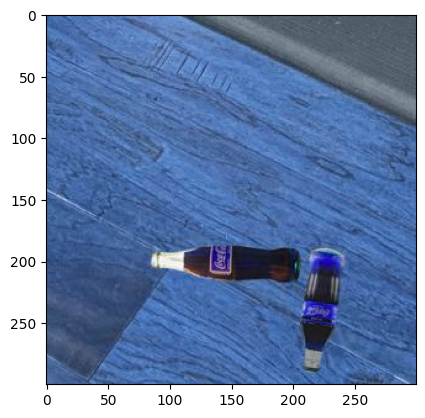

In [6]:
img = cv2.imread(os.path.join(data, 'Soda Bottle', '00000000.jpg'))
plt.imshow(img)
plt.show()

### Resize seluruh gambar ke ukuran 150x10 untuk increase Training Time

In [7]:
import PIL
import os.path
from PIL import Image

f = os.path.join(data, 'Wine Bottle')
for file in os.listdir(f):
    f_img = os.path.join(f, file)
    img = Image.open(f_img)
    img = img.resize((150,150))
    img.save(f_img)

### Augmentasi Data

In [8]:
train_generator = ImageDataGenerator(
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest',
    horizontal_flip=True,
    rescale=1./255,
    validation_split=0.2
)

test_generator = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [9]:
data_train = train_generator.flow_from_directory (
    data,
    target_size=(150,150),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    subset='training'
)

Found 20000 images belonging to 5 classes.


In [10]:
data_test = test_generator.flow_from_directory (
    data,
    target_size=(150,150),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    subset='validation'
)

Found 5000 images belonging to 5 classes.


### Define Learning Rate

In [11]:
optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0)

d:\IDCAMP\Gen AI\.conda\Lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


### Arsitektur Model

In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax'),
])
model.compile(loss = "categorical_crossentropy", optimizer = optimizer , metrics = ["accuracy"])

d:\IDCAMP\Gen AI\.conda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Define Callbacks

In [13]:
# Callback agar model berhenti saat val_accuracy melampaui 97%
class MyCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get('val_accuracy')
        if val_acc is not None and val_acc > 0.97:
            print("\nVal accuracy telah melampaui 97%, membatalkan proses training")
            self.model.stop_training = True

callbacks = MyCallback()

### Define Early Stop Training per 10 epochs 

In [14]:
checkpoint = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

In [ ]:
# Re-compile model dengan optimizer yang stabil untuk Keras versi terbaru
optimizer = Adam(learning_rate=0.001)
model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"] )

history = model.fit(
    data_train,
    steps_per_epoch=max(1, data_train.samples // data_train.batch_size),
    epochs=32,
    validation_data=data_test,
    validation_steps=max(1, data_test.samples // data_test.batch_size),
    callbacks=[checkpoint, callbacks]
 )

Epoch 1/32
455/625 ━━━━━━━━━━━━━━━━━━━━ 1:11 419ms/step - accuracy: 0.3440 - loss: 1.4293

### Model Summary

In [ ]:
model.summary()

### Plot Loss dan Akurasi

In [ ]:
fig, axarr = plt.subplots(1,2, figsize=(15,5), sharex=True)

sns.set(style="ticks", font_scale = 1)
sns.despine(top=True, right=True, left=False, bottom=False)

historyDF = pd.DataFrame.from_dict(history.history)
ax = sns.lineplot(x = historyDF.index, y = history.history['accuracy'], ax=axarr[0], label="Training");
ax = sns.lineplot(x = historyDF.index, y = history.history['val_accuracy'], ax=axarr[0], label="Validation");
ax.set_ylabel('Accuracy')

ax = sns.lineplot(x = historyDF.index, y = history.history['loss'], ax=axarr[1], label="Training");
ax = sns.lineplot(x = historyDF.index, y = history.history['val_loss'], ax=axarr[1], label="Validation");
ax.set_ylabel('Loss')


axarr[0].set_title('Accuracy')
axarr[1].set_title('Loss')

for ax in axarr:
    ax.set_xlabel('Epochs')

plt.suptitle('Training and Performance Model', fontsize=16, weight='bold');
fig.tight_layout(pad=3.0)
plt.show()

### Save Model

In [ ]:
# Simpan semua artefak model sesuai struktur folder submission
BASE_DIR = os.getcwd()
SAVED_MODEL_DIR = os.path.join(BASE_DIR, "saved_model")
TFLITE_DIR = os.path.join(BASE_DIR, "tflite")
TFJS_DIR = os.path.join(BASE_DIR, "tfjs_model")

os.makedirs(SAVED_MODEL_DIR, exist_ok=True)
os.makedirs(TFLITE_DIR, exist_ok=True)
os.makedirs(TFJS_DIR, exist_ok=True)

tf.saved_model.save(model, SAVED_MODEL_DIR)
print("SavedModel tersimpan di:", SAVED_MODEL_DIR)

### Convert Model to TFLite

In [ ]:
# Convert ke TFLite dan simpan label
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)
tflite_model = converter.convert()

TFLITE_MODEL_PATH = os.path.join(TFLITE_DIR, "model.tflite")
with tf.io.gfile.GFile(TFLITE_MODEL_PATH, "wb") as f:
    f.write(tflite_model)

LABEL_PATH = os.path.join(TFLITE_DIR, "label.txt")
with open(LABEL_PATH, "w", encoding="utf-8") as f:
    for label in class_names:
        f.write(f"{label}\n")

print("TFLite model tersimpan di:", TFLITE_MODEL_PATH)
print("Label tersimpan di:", LABEL_PATH)

# Convert ke TFJS bila package tensorflowjs tersedia
try:
    if importlib.util.find_spec("tensorflowjs") is None:
        print("tensorflowjs belum terpasang. Lewati export TFJS.")
    else:
        subprocess.check_call([
            sys.executable,
            "-m",
            "tensorflowjs.converters.converter",
            "--input_format=tf_saved_model",
            "--output_format=tfjs_graph_model",
            SAVED_MODEL_DIR,
            TFJS_DIR,
        ])
        print("TFJS model tersimpan di:", TFJS_DIR)
except Exception as err:
    print("Export TFJS gagal:", err)

### Inference Menggunakan Model TFLite

In [ ]:
# Inference contoh dengan model TFLite
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

sample_image_path = os.path.join(data, class_names[0], os.listdir(os.path.join(data, class_names[0]))[0])
sample_img = cv2.imread(sample_image_path)
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
sample_img = cv2.resize(sample_img, (150, 150))
sample_input = (sample_img.astype(np.float32) / 255.0)
sample_input = np.expand_dims(sample_input, axis=0)

interpreter.set_tensor(input_details[0]["index"], sample_input)
interpreter.invoke()
pred = interpreter.get_tensor(output_details[0]["index"])[0]

pred_idx = int(np.argmax(pred))
pred_label = class_names[pred_idx]

print("Contoh gambar:", sample_image_path)
print("Prediksi kelas:", pred_label)
print("Skor probabilitas:", float(pred[pred_idx]))